<a href="https://colab.research.google.com/github/avxsharma-glitch/EDA---Exploratory-Data-Analysis/blob/Car-market-analysis/Car_market_analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Loaded Successfully!

Dataset Shape:
(301, 9)

First 5 Rows:
  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 

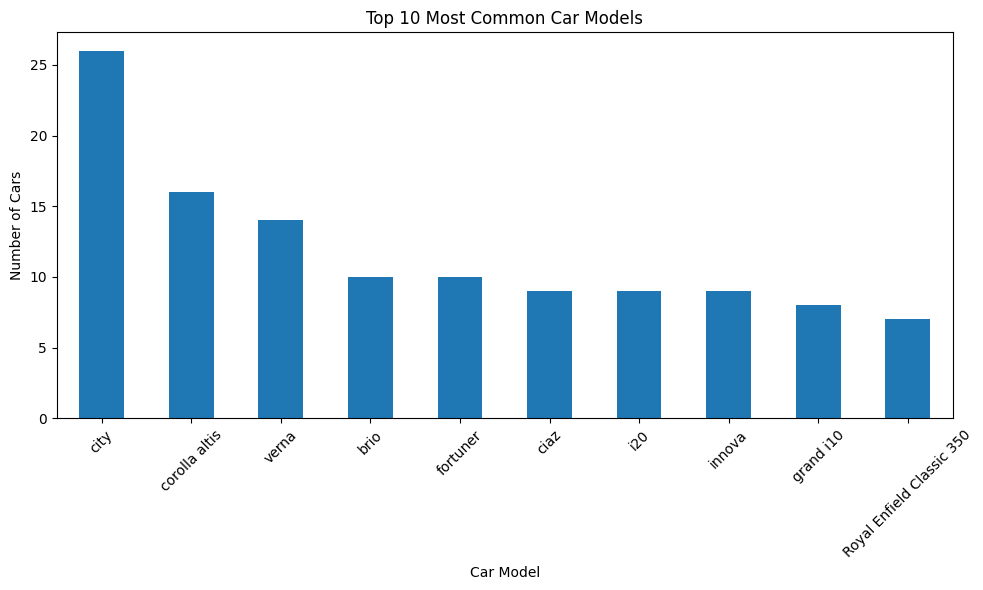

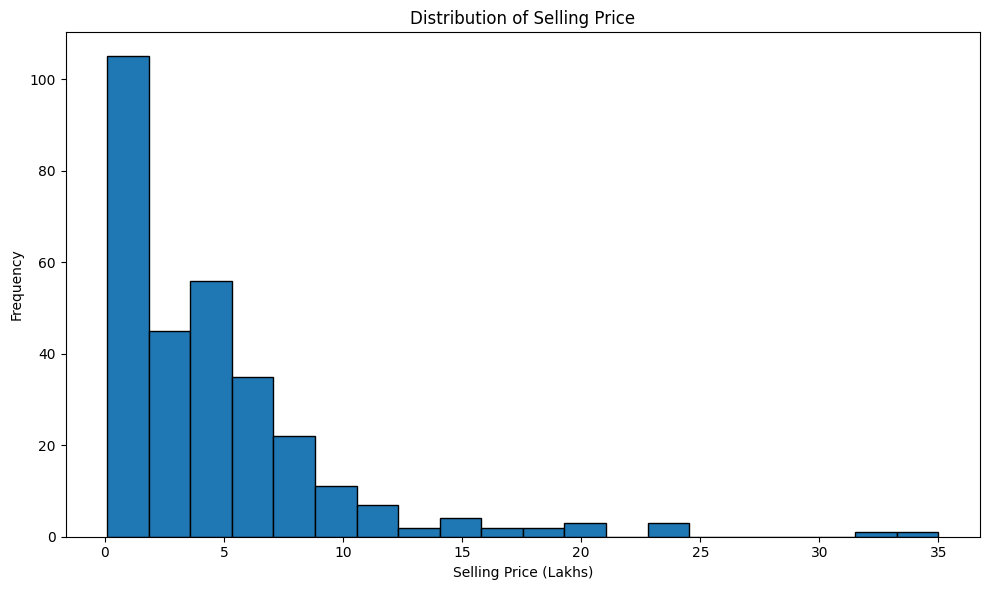


Average Selling Price by Fuel Type:
Fuel_Type
Diesel    10.102759
Petrol     3.264184
CNG        3.100000
Name: Selling_Price, dtype: float64


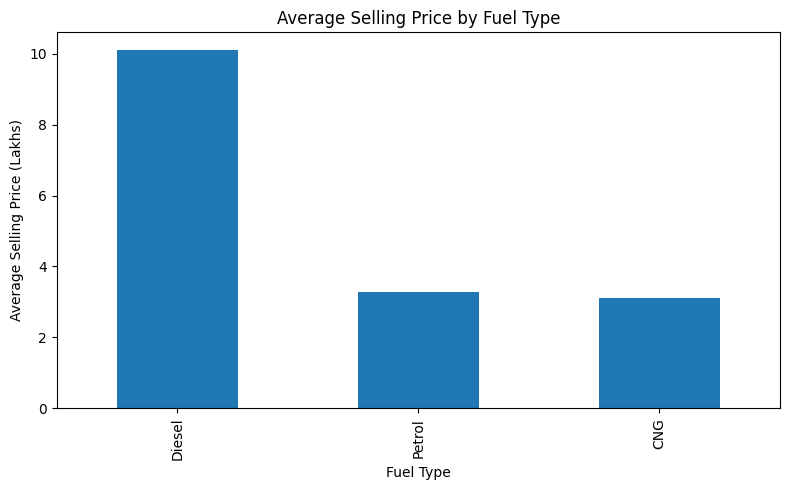

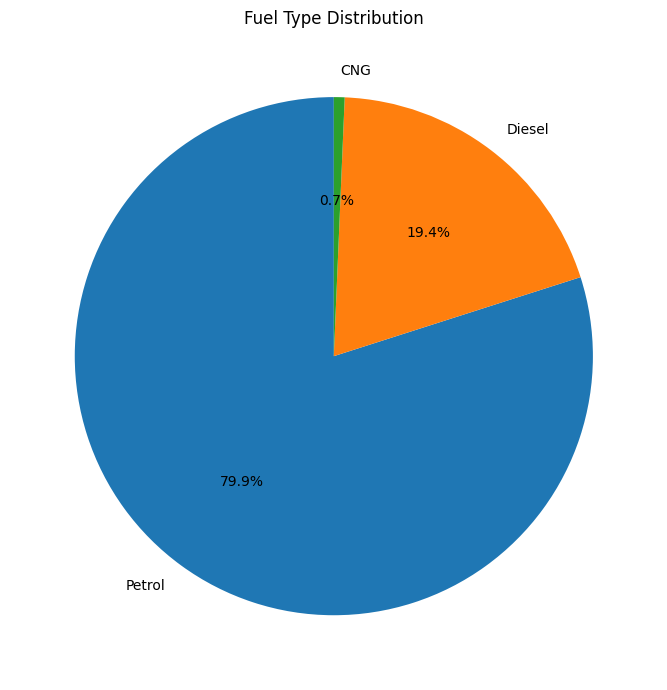


Average Selling Price by Seller Type:
Seller_Type
Dealer        6.632021
Individual    0.870943
Name: Selling_Price, dtype: float64


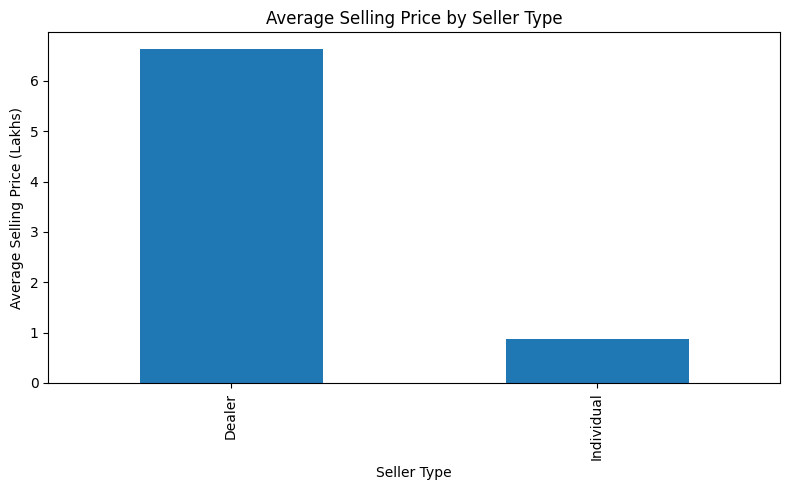


Average Selling Price by Transmission:
Transmission
Automatic    9.071795
Manual       3.917308
Name: Selling_Price, dtype: float64


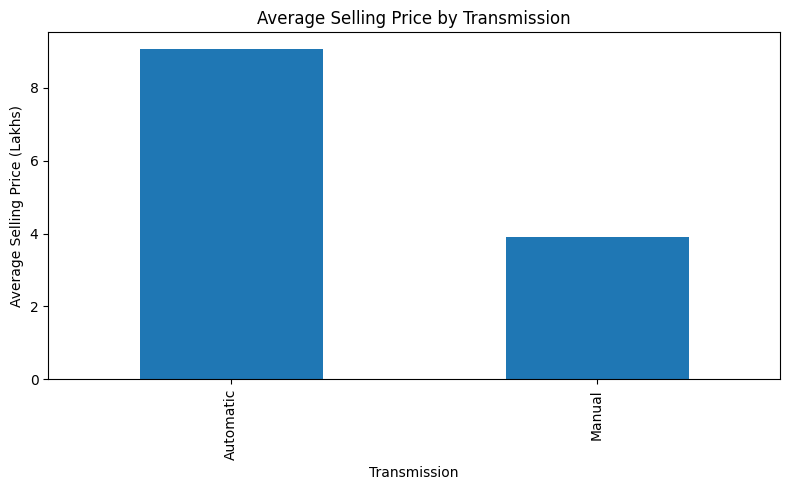

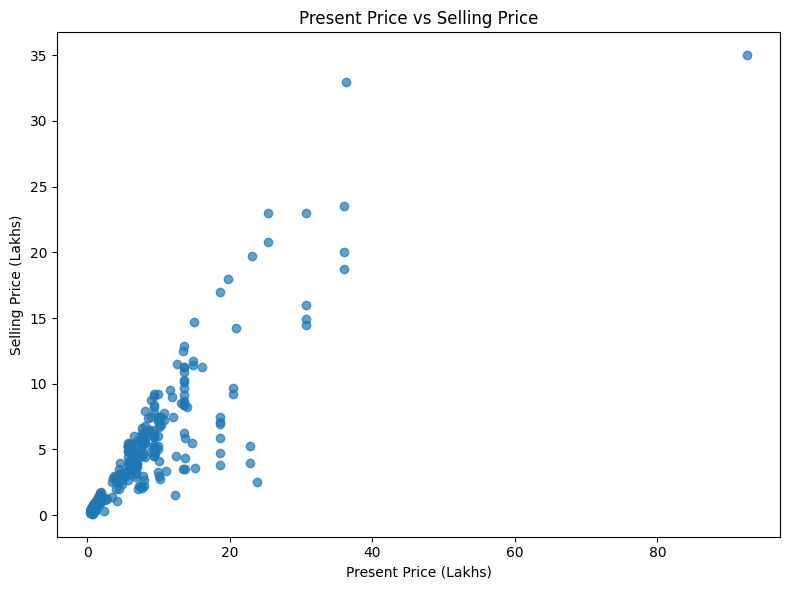

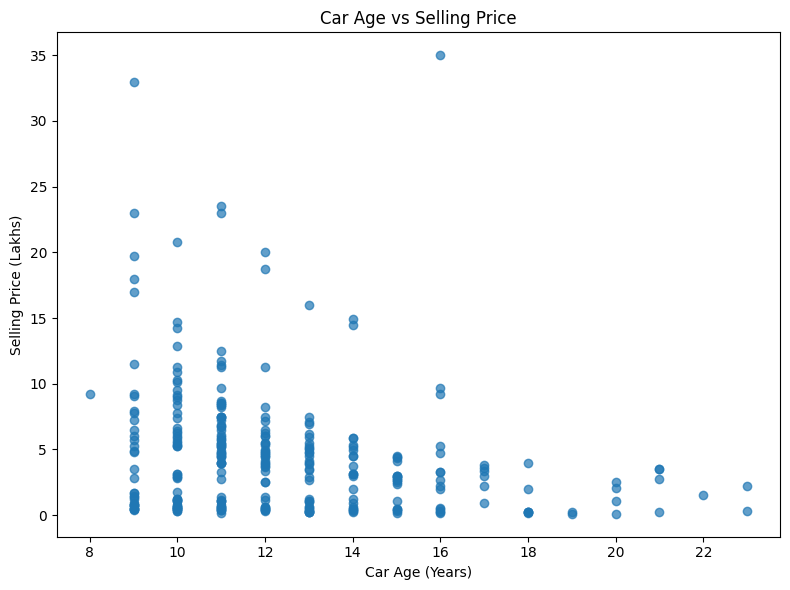

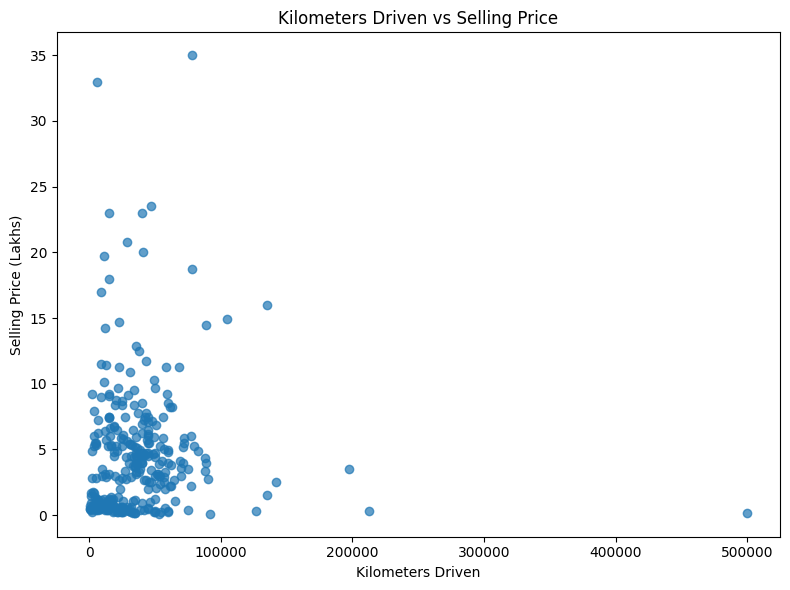


Correlation Matrix:
                             Year  Selling_Price  Present_Price  Kms_Driven  \
Year                     1.000000       0.234369      -0.053563   -0.525714   
Selling_Price            0.234369       1.000000       0.876378    0.028566   
Present_Price           -0.053563       0.876378       1.000000    0.205253   
Kms_Driven              -0.525714       0.028566       0.205253    1.000000   
Owner                   -0.181639      -0.087880       0.009947    0.089367   
Car_Age                 -1.000000      -0.234369       0.053563    0.525714   
Depreciation_Percentage -0.848636      -0.230115       0.109518    0.506720   

                            Owner   Car_Age  Depreciation_Percentage  
Year                    -0.181639 -1.000000                -0.848636  
Selling_Price           -0.087880 -0.234369                -0.230115  
Present_Price            0.009947  0.053563                 0.109518  
Kms_Driven               0.089367  0.525714                 0.

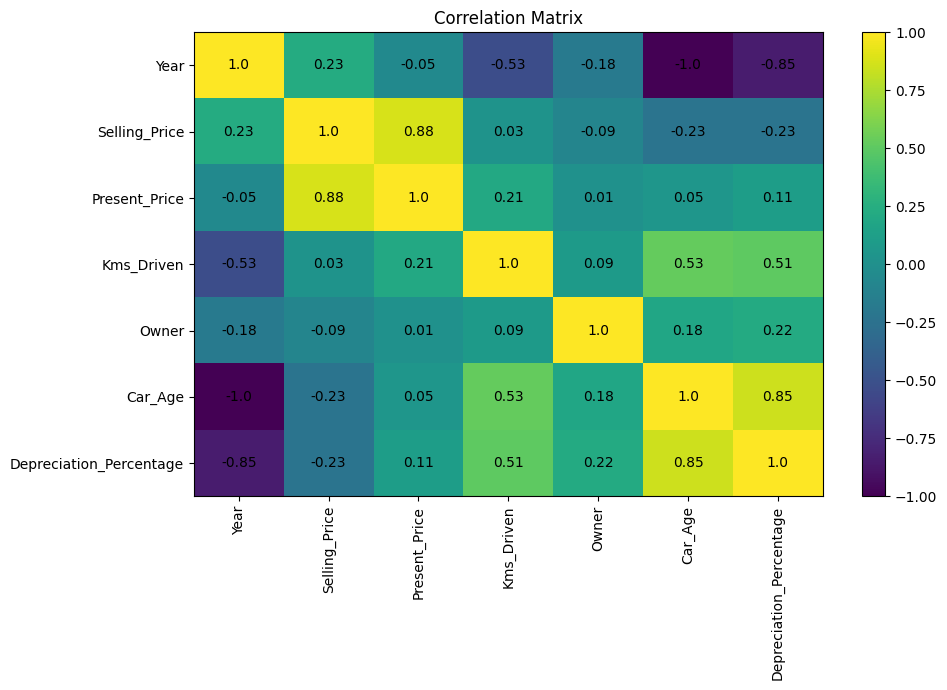

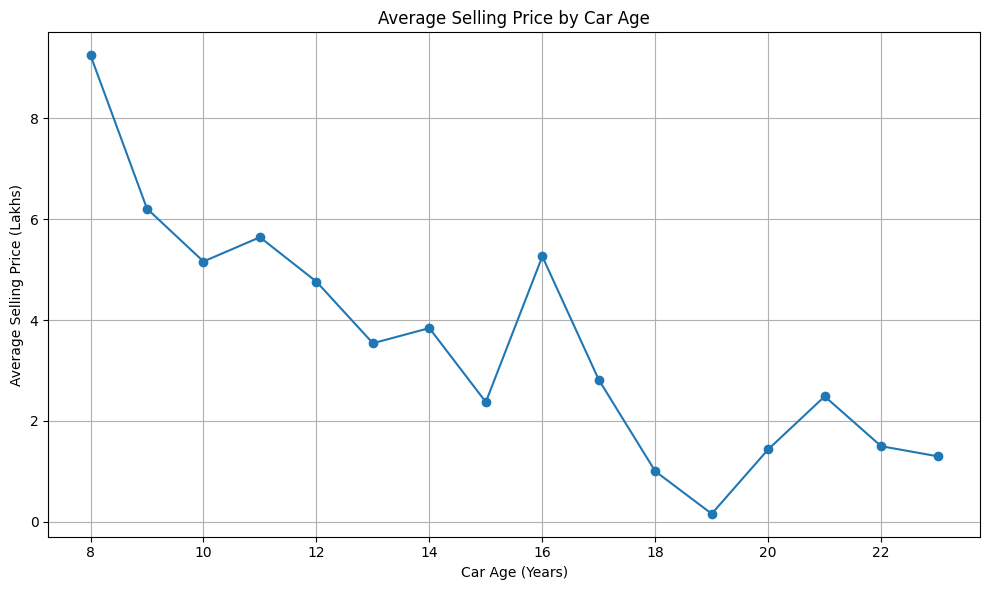


Average Depreciation Percentage:
36.62 %


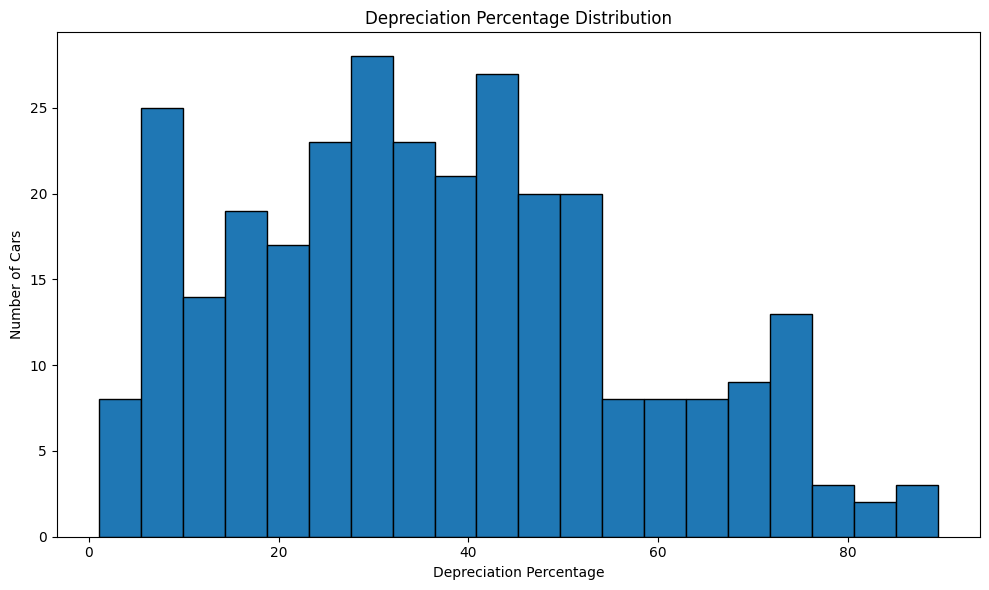


MODEL PERFORMANCE
Mean Absolute Error: 1.555
Mean Squared Error: 14.245
Root Mean Squared Error: 3.774
R² Score: 0.447


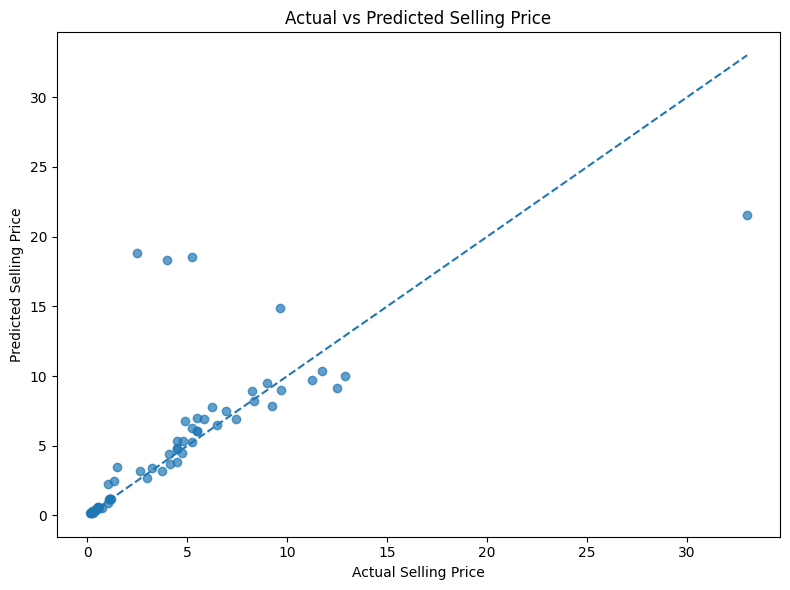


Feature Importance:
Present_Price    0.902300
Year             0.039085
Car_Age          0.038418
Kms_Driven       0.011558
Transmission     0.005155
Seller_Type      0.002074
Fuel_Type        0.001400
Owner            0.000009
dtype: float64


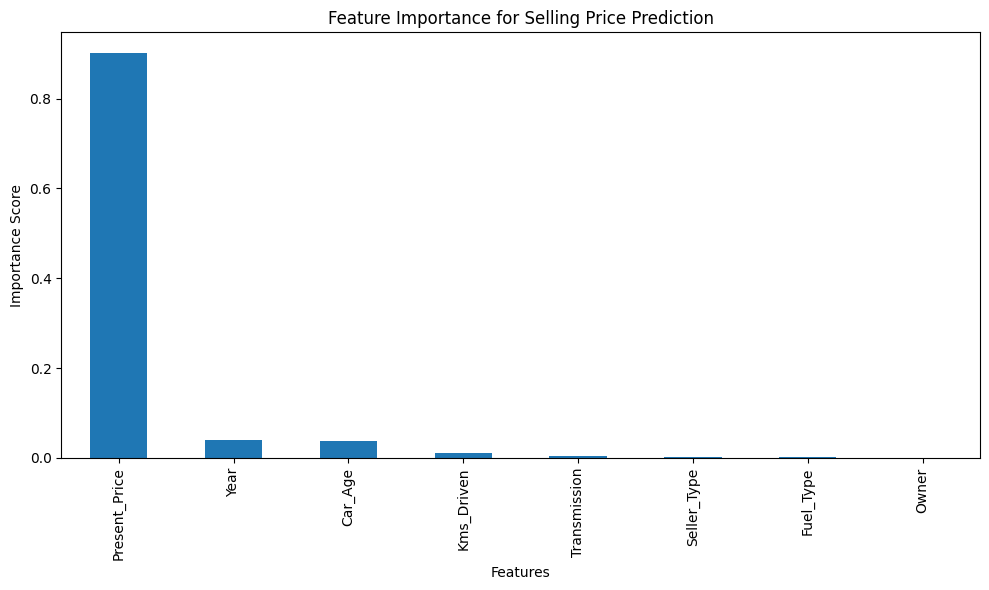


Cleaned Dataset Saved Successfully!

FINAL DATASET INSIGHTS

Total Cars: 299
Average Selling Price: 4.59 Lakhs
Average Car Age: 12.38 Years
Most Common Fuel Type: Petrol
Most Common Transmission: Manual
Most Common Seller Type: Dealer
Average Depreciation: 36.62 %

Analysis Completed Successfully!
All graphs have been saved as PNG files.


In [ ]:
# ============================================================
# CAR MARKET TRENDS ANALYSIS - CARDEKHO DATASET
# ============================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv("1776311302-P3-Car Market Trends Analysis with Car Dekho Data.csv")

print("Dataset Loaded Successfully!")
print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())


# ============================================================
# 2. BASIC DATA INFORMATION
# ============================================================

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


# ============================================================
# 3. DATA CLEANING
# ============================================================

# Remove duplicate rows
df = df.drop_duplicates()

# Remove rows with missing values
df = df.dropna()

print("\nDataset Shape After Cleaning:")
print(df.shape)


# ============================================================
# 4. FEATURE ENGINEERING
# ============================================================

# Current year
CURRENT_YEAR = 2026

# Calculate age of car
df["Car_Age"] = CURRENT_YEAR - df["Year"]

# Calculate depreciation percentage
df["Depreciation_Percentage"] = (
    (df["Present_Price"] - df["Selling_Price"])
    / df["Present_Price"]
) * 100

print("\nNew Features Created:")
print(df[["Car_Name", "Year", "Car_Age",
          "Present_Price", "Selling_Price",
          "Depreciation_Percentage"]].head())


# ============================================================
# 5. TOP 10 MOST COMMON CAR MODELS
# ============================================================

top_cars = df["Car_Name"].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_cars.plot(kind="bar")

plt.title("Top 10 Most Common Car Models")
plt.xlabel("Car Model")
plt.ylabel("Number of Cars")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("01_top_car_models.png")
plt.show()


# ============================================================
# 6. SELLING PRICE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    df["Selling_Price"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price (Lakhs)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("02_selling_price_distribution.png")
plt.show()


# ============================================================
# 7. AVERAGE SELLING PRICE BY FUEL TYPE
# ============================================================

fuel_price = (
    df.groupby("Fuel_Type")["Selling_Price"]
    .mean()
    .sort_values(ascending=False)
)

print("\nAverage Selling Price by Fuel Type:")
print(fuel_price)

plt.figure(figsize=(8, 5))
fuel_price.plot(kind="bar")

plt.title("Average Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Selling Price (Lakhs)")

plt.tight_layout()
plt.savefig("03_average_price_by_fuel.png")
plt.show()


# ============================================================
# 8. FUEL TYPE DISTRIBUTION
# ============================================================

fuel_count = df["Fuel_Type"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    fuel_count,
    labels=fuel_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Fuel Type Distribution")

plt.tight_layout()
plt.savefig("04_fuel_type_distribution.png")
plt.show()


# ============================================================
# 9. SELLER TYPE ANALYSIS
# ============================================================

seller_price = (
    df.groupby("Seller_Type")["Selling_Price"]
    .mean()
    .sort_values(ascending=False)
)

print("\nAverage Selling Price by Seller Type:")
print(seller_price)

plt.figure(figsize=(8, 5))
seller_price.plot(kind="bar")

plt.title("Average Selling Price by Seller Type")
plt.xlabel("Seller Type")
plt.ylabel("Average Selling Price (Lakhs)")

plt.tight_layout()
plt.savefig("05_seller_type_analysis.png")
plt.show()


# ============================================================
# 10. TRANSMISSION ANALYSIS
# ============================================================

transmission_price = (
    df.groupby("Transmission")["Selling_Price"]
    .mean()
    .sort_values(ascending=False)
)

print("\nAverage Selling Price by Transmission:")
print(transmission_price)

plt.figure(figsize=(8, 5))
transmission_price.plot(kind="bar")

plt.title("Average Selling Price by Transmission")
plt.xlabel("Transmission")
plt.ylabel("Average Selling Price (Lakhs)")

plt.tight_layout()
plt.savefig("06_transmission_analysis.png")
plt.show()


# ============================================================
# 11. SELLING PRICE VS PRESENT PRICE
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    df["Present_Price"],
    df["Selling_Price"],
    alpha=0.7
)

plt.title("Present Price vs Selling Price")
plt.xlabel("Present Price (Lakhs)")
plt.ylabel("Selling Price (Lakhs)")

plt.tight_layout()
plt.savefig("07_present_vs_selling_price.png")
plt.show()


# ============================================================
# 12. CAR AGE VS SELLING PRICE
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    df["Car_Age"],
    df["Selling_Price"],
    alpha=0.7
)

plt.title("Car Age vs Selling Price")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price (Lakhs)")

plt.tight_layout()
plt.savefig("08_car_age_vs_selling_price.png")
plt.show()


# ============================================================
# 13. KILOMETERS DRIVEN VS SELLING PRICE
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    df["Kms_Driven"],
    df["Selling_Price"],
    alpha=0.7
)

plt.title("Kilometers Driven vs Selling Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price (Lakhs)")

plt.tight_layout()
plt.savefig("09_kms_vs_selling_price.png")
plt.show()


# ============================================================
# 14. CORRELATION ANALYSIS
# ============================================================

numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

print("\nCorrelation Matrix:")
print(correlation)

plt.figure(figsize=(10, 7))

plt.imshow(correlation, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

# Add correlation values
for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(
            j,
            i,
            round(correlation.iloc[i, j], 2),
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.savefig("10_correlation_matrix.png")
plt.show()


# ============================================================
# 15. AVERAGE PRICE BY CAR AGE
# ============================================================

age_price = (
    df.groupby("Car_Age")["Selling_Price"]
    .mean()
)

plt.figure(figsize=(10, 6))

plt.plot(
    age_price.index,
    age_price.values,
    marker="o"
)

plt.title("Average Selling Price by Car Age")
plt.xlabel("Car Age (Years)")
plt.ylabel("Average Selling Price (Lakhs)")

plt.grid(True)
plt.tight_layout()

plt.savefig("11_average_price_by_age.png")
plt.show()


# ============================================================
# 16. DEPRECIATION ANALYSIS
# ============================================================

print("\nAverage Depreciation Percentage:")
print(
    round(
        df["Depreciation_Percentage"].mean(),
        2
    ),
    "%"
)

plt.figure(figsize=(10, 6))

plt.hist(
    df["Depreciation_Percentage"],
    bins=20,
    edgecolor="black"
)

plt.title("Depreciation Percentage Distribution")
plt.xlabel("Depreciation Percentage")
plt.ylabel("Number of Cars")

plt.tight_layout()
plt.savefig("12_depreciation_distribution.png")
plt.show()


# ============================================================
# 17. MACHINE LEARNING - SELLING PRICE PREDICTION
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Create copy for machine learning
ml_df = df.copy()


# Remove Car_Name because there are many unique values
ml_df = ml_df.drop("Car_Name", axis=1)


# Encode categorical columns
categorical_columns = [
    "Fuel_Type",
    "Seller_Type",
    "Transmission"
]

for column in categorical_columns:

    le = LabelEncoder()

    ml_df[column] = le.fit_transform(
        ml_df[column]
    )


# Define Features and Target
X = ml_df.drop(
    [
        "Selling_Price",
        "Depreciation_Percentage"
    ],
    axis=1
)

y = ml_df["Selling_Price"]


# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# Create Model
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)


# Train Model
model.fit(
    X_train,
    y_train
)


# Predictions
predictions = model.predict(
    X_test
)


# ============================================================
# 18. MODEL EVALUATION
# ============================================================

mae = mean_absolute_error(
    y_test,
    predictions
)

mse = mean_squared_error(
    y_test,
    predictions
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    predictions
)


print("\nMODEL PERFORMANCE")

print("Mean Absolute Error:", round(mae, 3))

print("Mean Squared Error:", round(mse, 3))

print("Root Mean Squared Error:", round(rmse, 3))

print("R² Score:", round(r2, 3))


# ============================================================
# 19. ACTUAL VS PREDICTED PRICES
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.7
)

min_value = min(y_test.min(), predictions.min())
max_value = max(y_test.max(), predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Actual vs Predicted Selling Price")
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")

plt.tight_layout()
plt.savefig("13_actual_vs_predicted.png")
plt.show()


# ============================================================
# 20. FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(
    ascending=False
)


print("\nFeature Importance:")
print(feature_importance)


plt.figure(figsize=(10, 6))

feature_importance.plot(
    kind="bar"
)

plt.title("Feature Importance for Selling Price Prediction")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.tight_layout()
plt.savefig("14_feature_importance.png")
plt.show()


# ============================================================
# 21. SAVE CLEANED DATASET
# ============================================================

df.to_csv(
    "cleaned_car_market_data.csv",
    index=False
)

print("\nCleaned Dataset Saved Successfully!")


# ============================================================
# 22. FINAL INSIGHTS
# ============================================================

print("\n" + "=" * 60)
print("FINAL DATASET INSIGHTS")
print("=" * 60)

print("\nTotal Cars:", len(df))

print(
    "Average Selling Price:",
    round(df["Selling_Price"].mean(), 2),
    "Lakhs"
)

print(
    "Average Car Age:",
    round(df["Car_Age"].mean(), 2),
    "Years"
)

print(
    "Most Common Fuel Type:",
    df["Fuel_Type"].mode()[0]
)

print(
    "Most Common Transmission:",
    df["Transmission"].mode()[0]
)

print(
    "Most Common Seller Type:",
    df["Seller_Type"].mode()[0]
)

print(
    "Average Depreciation:",
    round(
        df["Depreciation_Percentage"].mean(),
        2
    ),
    "%"
)

print("\nAnalysis Completed Successfully!")
print("All graphs have been saved as PNG files.")